In [ ]:
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.animation as animation

import astropy.units as u
import astropy.constants as const
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, SkyOffsetFrame


from scipy.sparse.linalg import eigsh
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize
from scipy.sparse.linalg import svds
from scipy.interpolate import griddata



import time as timer

import sys
sys.path.append('..')  # Add parent directory to the system path

from pint.models import get_model
from RickettTables import fitvals
from RickettEquations import *
from Curvature import *

import scintools2.scintools.ththmod as thth
from scintools2.scintools.dynspec import BasicDyn, Dynspec



import gc
from multiprocessing import Pool
from tqdm.notebook import tqdm

import warnings

warnings.filterwarnings("ignore", message="divide by zero encountered in divide")
biharmonic = False

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

: 

In [4]:
from Funcs_DP import *
from Funcs_DP_Orbsim import *
from Funcs_DP_Sspec import *
from Funcs_DP_thth import *
from Aux_funcs import *

ModuleNotFoundError: No module named 'Funcs_DP'

In [5]:
from astropy.visualization import quantity_support
from pint.simulation import make_fake_toas_uniform
from pint.models import get_model
from numpy.polynomial.polynomial import Polynomial

def get_pulsar_model(parfile, times, **kwargs):
    model = get_model(parfile)
    toa = make_fake_toas_uniform(times[0].mjd, times[-1].mjd, len(times),
                                 model, **kwargs)
    # Ensure times are inside model so bm.E() gets appropriate numbers.
    model.update_binary_object(toa)
    return model

In [ ]:
full_sorted = meerkat_data_extractor( '/fs/lustre/scratch/montalvo/meerkat/Obs' )

NameError: name 'meerkat_data_extractor' is not defined

: 

In [ ]:
currentobs = '2023-5-16'
band = 'S'

In [ ]:
datpath = '/fs/lustre/scratch/montalvo/meerkat_npz/bands/' + band + '/' + currentobs + '/inferred_data_' + currentobs + '_re.npz'
data_tmp = np.load(datpath)


tli = 1
ts = data_tmp['time'][:-tli] * u.hour
fs = data_tmp['freq'] * u.MHz
ds = dynamic_spectrum_averager( data_tmp['dspec'][:,:-tli] )
mjds = data_tmp['mjd']
phase = data_tmp['phase'][:-tli] * u.rad
nu = data_tmp['nu'][:-tli] * u.rad
a_guess = data_tmp['a_guess'] 
atol = data_tmp['atol']
atol_hard = data_tmp['atol_hard']
y = data_tmp['y'][:-tli]

# ds = ds / thth.svd_model( ds ).real

print(data_tmp['interest'])
print( ds.shape )
fs

H
(16384, 1350)


<Quantity [1749.599487, 1749.652832, 1749.706299, ..., 2624.439209,
           2624.492676, 2624.546143] MHz>

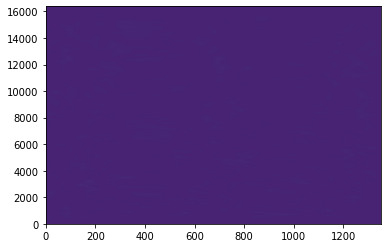

In [ ]:
m = ds[2000:14000].mean()
plt.imshow(ds/m, origin='lower', aspect='auto', vmin=0, vmax=10)

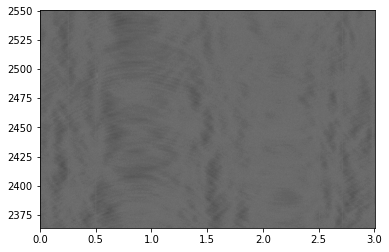

In [ ]:
# Pick frequency part that shows clearest coherent structure.

ki = 11500
kf = 15000
slc = slice(ki, kf)
# slc = slice(2000, 15000)
dsx = ds[slc]
n = dsx/dsx.mean()-1.
plt.imshow(n, origin='lower', aspect='auto', vmin=-1, vmax=0.5, cmap='Greys',
          extent = ext_find( ts, fs[ki:kf]))
# nice reversal between ~230 and ~600; pattern spacing ~60: tau=3500/60~60.

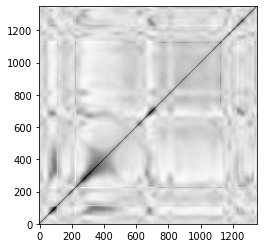

In [ ]:
# Calculate correlation of each spectrum with every other, to see if
# spectra are the same at different times
c = (n.T @ n) / np.sqrt((n**2).sum(0) * (n**2).sum(0)[:, np.newaxis])
plt.imshow(c, origin='lower', vmin=-0.1, vmax=0.3, cmap='Greys')
# Clearly correlated symm. around 390, up to 265/530

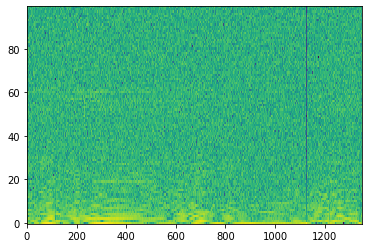

In [ ]:
# Calculate delay spectrum as a function of time (just one dimension,
# to see how things vary).
dtau = np.fft.rfft(n, axis=0)
plt.imshow(2*np.log10(np.abs(dtau[:100])), aspect='auto', origin='lower', vmin=-4, interpolation='none')


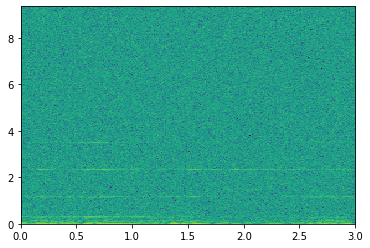

In [ ]:
# Signal at tau=60 from ~60 to 530; tau=19 from ~270 to 510
# Easier to see in smoothed dynamic spectrum
sp = 5

ns = n[:, :(n.shape[1] // sp) * sp].reshape(n.shape[0], -1, sp).mean(-1)
tss = ts[:(n.shape[1] // sp) * sp].reshape(-1, sp).mean(-1)

dtaus = np.fft.rfft(ns, axis=0)
taus = np.fft.rfftfreq(ns.shape[0], fs[1]-fs[0]).to(u.us)
plt.imshow(2*np.log10(np.abs(dtaus[:-1])), aspect='auto', origin='lower', vmin=-4, interpolation='none',
          extent = ext_find( tss, fft_axis(fs[ki:kf], u.us)[-fs[ki:kf].shape[0] // 2 :]) )

## original code
## ---------------------------------------------------------------

In [ ]:
# real, imag, abs, and angle as a function of time.
f = dtaus[tau_sel]
sel_fit = (tss < 1.3 * u.hour) # & (tss > 0.5 * u.hour)
f = dtaus[56]  # Narrower range that's OK.
sel_fit = (tss > 0.55 *u.hour) & (tss < 1.35 * u.hour)
f = dtaus[60]
sel_fit = (tss < 1.3 * u.hour)
e_f = dtaus[55:65].std() / np.sqrt(2)  # Noise in real, imag comp.
ang = np.degrees(np.angle(f)) << u.deg
a_corr = np.sqrt(np.maximum(f.real**2 + f.imag**2 - 2*e_f**2,
                            (e_f/np.pi)**2))
e_ang = np.degrees(e_f / a_corr) << u.deg
unwrapped = np.unwrap(ang)
# actual time
t = Time(mjds, tss.to_value(u.day), format='mjd')
if 'psr_m' not in locals() or len(E) != len(tss):
    psr_m = get_pulsar_model("J0737-3039A-2021.par", times=t,
                             freq=fs.mean(), obs="GBT")
bm = psr_m.binary_instance
# E gives 347; checked that bm.nu() and bm.M() gives worse chi2: 369 and 395.
E = bm.E().astype(float)
E_unwrapped = np.unwrap(E) - 1*u.cy
t_int = np.linspace(ts.min(), ts.max(), 10001)
E_int = np.interp(t_int, tss, E_unwrapped)

2025-09-04 12:49:55.738 | DEBUG    | pint.toa:__init__:1345 - No pulse number flags found in the TOAs
2025-09-04 12:49:55.740 | DEBUG    | pint.toa:apply_clock_corrections:2187 - Applying clock corrections (include_gps = True, include_bipm = False)
2025-09-04 12:49:55.759 | INFO     | pint.observatory:gps_correction:209 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-09-04 12:49:55.760 | INFO     | pint.observatory.topo_obs:clock_corrections:342 - Applying observatory clock corrections for observatory='gbt'.
2025-09-04 12:49:55.880 | DEBUG    | pint.toa:compute_TDBs:2238 - Computing TDB columns.
2025-09-04 12:49:55.880 | DEBUG    | pint.toa:compute_TDBs:2259 - Using EPHEM = DE405 for TDB calculation.
2025-09-04 12:49:55.921 | DEBUG    | pint.toa:compute_posvels:2337 - Computing PosVels of observatories and Earth, using DE405
2025-09-04 12:49:56.107 | INFO     | pint.solar_system_ephemerides:_load_kernel_link:55 - Set solar system ephemeris to de405 from download
2025-09-

2025-09-04 12:49:57.484 | DEBUG    | pint.toa:compute_posvels:2342 - Column obs_sun_pos already exists. Removing...
2025-09-04 12:49:57.653 | INFO     | pint.solar_system_ephemerides:_load_kernel_link:55 - Set solar system ephemeris to de405 from download
2025-09-04 12:49:57.689 | DEBUG    | pint.toa:compute_posvels:2390 - SSB obs pos [-8.79688411e+10 -1.13899027e+11 -4.93335441e+10] m
2025-09-04 12:49:57.850 | INFO     | pint.solar_system_ephemerides:_load_kernel_link:55 - Set solar system ephemeris to de405 from download
2025-09-04 12:49:57.851 | DEBUG    | pint.toa:compute_posvels:2404 - Adding columns ssb_obs_pos ssb_obs_vel obs_sun_pos
2025-09-04 12:49:57.934 | DEBUG    | pint.models.solar_system_shapiro:solar_system_shapiro_delay:102 - Skipping Shapiro delay for Barycentric TOAs
2025-09-04 12:49:58.053 | DEBUG    | pint.toa:compute_TDBs:2238 - Computing TDB columns.
2025-09-04 12:49:58.053 | DEBUG    | pint.toa:compute_TDBs:2240 - tdb column already exists. Deleting...
2025-09-04

Text(0.5, 1.0, '$\\tau_D = $0.321 ($\\mu$s)')

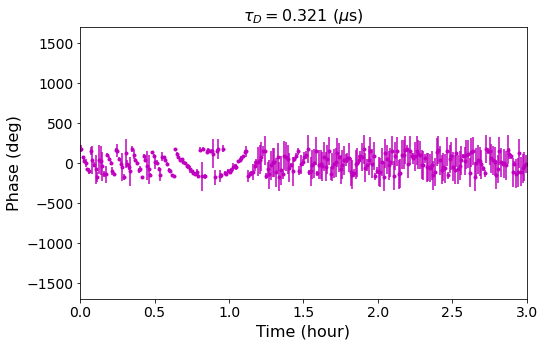

In [ ]:
plt.figure(figsize = (8,5))
plt.errorbar(tss, ang, e_ang, c='m', fmt='.')
# plt.errorbar(tss, unwrapped, e_ang, c='m', fmt='.')

plt.xlim(0,3)

plt.ylim(-1700,1700)

plt.ylabel('Phase (deg)', fontsize = 16)
plt.xlabel('Time (hour)', fontsize = 16)

plt.tick_params(axis='both', which='major', labelsize=14)
plt.title('$\\tau_D = $' + d2str(fft_axis(fs[ki:kf], u.us)[-fs[ki:kf].shape[0] // 2 :][tau_sel].value,3) + " ($\mu$s)", fontsize = 16)

## -----------------------------------

Text(0.5, 1.0, '$\\tau_D = $0.321 ($\\mu$s)')

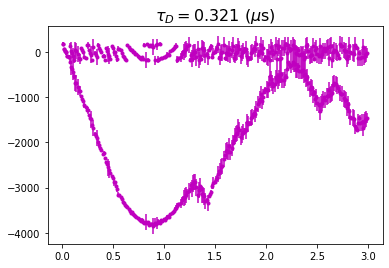

In [ ]:
tau_sel = 60

# real, imag, abs, and angle as a function of time.
f = dtaus[tau_sel]
sel_fit = (tss < 1.3 * u.hour) # & (tss > 0.5 * u.hour)
# f = dtaus[56]  # Narrower range that's OK.
# sel_fit = (tss > 0.55 *u.hour) & (tss < 1.35 * u.hour)
# f = dtaus[61]
# sel_fit = (tss < 1.3 * u.hour)
e_f = dtaus[tau_sel-5:tau_sel+5].std() / np.sqrt(2)  # Noise in real, imag comp.
ang = np.degrees(np.angle(f)) << u.deg
a_corr = np.sqrt(np.maximum(f.real**2 + f.imag**2 - 2*e_f**2,
                            (e_f/np.pi)**2))
e_ang = np.degrees(e_f / a_corr) << u.deg
unwrapped = np.unwrap(ang)

plt.errorbar(tss, ang, e_ang, c='m', fmt='.')
plt.errorbar(tss, unwrapped, e_ang, c='m', fmt='.')


plt.title('$\\tau_D = $' + d2str(fft_axis(fs[ki:kf], u.us)[-fs[ki:kf].shape[0] // 2 :][tau_sel].value,3) + " ($\mu$s)", fontsize = 16)

In [ ]:

# actual time
t = Time(mjds, tss.to_value(u.day), format='mjd')
if 'psr_m' not in locals() or len(E) != len(tss):
    psr_m = get_pulsar_model("J0737-3039A-2021.par", times=t,
                             freq=fs.mean(), obs="GBT")
bm = psr_m.binary_instance
# E gives 347; checked that bm.nu() and bm.M() gives worse chi2: 369 and 395.
E = bm.E().astype(float)
E_unwrapped = np.unwrap(E) - 1*u.cy
t_int = np.linspace(ts.min(), ts.max(), 10001)
E_int = np.interp(t_int, tss, E_unwrapped)

In [ ]:
nu_p_om = bm.nu() + bm.omega()
nu_p_om = (nu_p_om - (nu_p_om[0] // (1*u.cy))*u.cy).astype(float)
# t0 = 0.87108681*u.hr  # gives first derivative 0 in polynomial fit with deg=4
# Relative to descending node, which is nicely in the middle of the good part.
t0 = np.interp(0.5*u.cy, nu_p_om, tss)
E0 = np.interp(t0, tss, E_unwrapped)
# Not really needed, it turns out.
# om0 = np.interp(t0, tss, bm.omega().astype(float)) % (1*u.cycle)
# nu0 = np.interp(t0, tss, bm.nu().astype(float)) % (1*u.cycle)
# assert u.isclose(om0+nu0, 0.5*u.cy)

In [ ]:
if True:
    # 4th degree wrt t gives chi2=310/(117-5); 6: 237/110; w/ E: 367, 236
    x_fit = tss - t0
    x_int = t_int - t0
    # With E the least-squares solution makes more sense, though fit
    # slightly less good.
    # xfit = E_unwrapped - E0
    # x_int = E_int - E0
    fit4, res4 = Polynomial.fit(x_fit.value[sel_fit], unwrapped[sel_fit], 4,
                                w=1/e_ang[sel_fit], domain=[], full=True)
    # p_fit = fit(xfit.value)
    # p_int = fit(x_int.value)
    # sel_int = (p_int < unwrapped.max()) & (p_fit_int > unwrapped.min())

In [ ]:
# Least squares fit to C0 + C1 * t + C2*np.cos(E) + C3*np.sin(E)
# chi2=347/(117-4)
# design matrix:  A sol = B, but weighted.  Standard linear least-square:
# A.T A sol = A.T B -> sol = (A.T A)^-1 A.T B ≡ C A.T B,
# with covariance matrix C = (A.T A)^-1.
def get_indep(t, E):
    return np.stack([np.ones(len(t)),
                     t.value,
                     np.cos(E).value,
                     np.sin(E).value
                     ], axis=-1)

In [ ]:
indep = get_indep(tss-t0, E-E0)
A = (indep / e_ang[:, np.newaxis]).value[sel_fit]
B = (unwrapped / e_ang).value[sel_fit]
C = np.linalg.inv(A.T @ A)  # Covariance matrix
sol = C @ A.T @ B
# Note: errors assume good fit (χ²ᵣ ~ 1), i.e., they are underestimated!
err = np.sqrt(np.diag(C))
# For default selection, highly covariant! Need to cover more of orbit
# to reduce covariance.
cov = C / np.outer(err, err)

# Check solution (lstsq does not give covariance matrix, otherwise we
# could just use it directly).
check, chi2, rank, s = np.linalg.lstsq(A, B, rcond=None)
ndof = len(B) - len(sol)
assert np.allclose(sol, check)

In [ ]:
s = [f"{s:7.1f}±{e:4.1f}" for s, e in zip(sol, err)]
c = [','.join([f"{_:+6.3f}" for _ in cov[i,:i]]) for i in range(4)]
print(f"solution = {s[0]}\n"
      f"         + {s[1]} t,      c={c[1]}\n"
      f"         + {s[2]} cos(E), c={c[2]}\n"
      f"         + {s[3]} sin(E), c={c[3]}\n"
      f"χ²/dof   = {chi2[0]:7.3f}/{ndof} = {chi2[0]/ndof:6.3f}\n"
)

p_fit = (sol @ indep.T) << ang.unit
p_int = (sol @ get_indep(t_int-t0, E_int-E0).T) << ang.unit
sel_int = slice(None)

def wrap180(a):
    return (a + 0.5*u.cy) % (1*u.cy) - 0.5*u.cy

solution = -1489.5±17.6
         +  -157.9±65.5 t,      c=+0.931
         + -2327.4±20.1 cos(E), c=-0.986,-0.939
         +   -35.0±27.1 sin(E), c=-0.853,-0.977,+0.875
χ²/dof   = 125.970/113 =  1.115



In [ ]:
s = [f"{s:7.1f}±{e:4.1f}" for s, e in zip(sol, err)]
c = [','.join([f"{_:+6.3f}" for _ in cov[i,:i]]) for i in range(4)]
print(f"solution = {s[0]}\n"
      f"         + {s[1]} t,      c={c[1]}\n"
      f"         + {s[2]} cos(E), c={c[2]}\n"
      f"         + {s[3]} sin(E), c={c[3]}\n"
      f"χ²/dof   = {chi2[0]:7.3f}/{ndof} = {chi2[0]/ndof:6.3f}\n"
)

p_fit = (sol @ indep.T) << ang.unit
p_int = (sol @ get_indep(t_int-t0, E_int-E0).T) << ang.unit
sel_int = slice(None)

def wrap180(a):
    return (a + 0.5*u.cy) % (1*u.cy) - 0.5*u.cy

solution = -1500.4±10.3
         +  -191.6±39.2 t,      c=+0.925
         + -2314.9±11.9 cos(E), c=-0.984,-0.933
         +   -24.6±16.4 sin(E), c=-0.843,-0.976,+0.865
χ²/dof   = 339.396/113 =  3.004



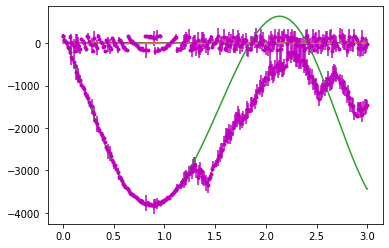

In [ ]:
if True:
    plt.errorbar(tss, f.real, e_f)
    plt.errorbar(tss, f.imag, e_f)
    plt.plot(tss, np.abs(f), c='k')
    plt.errorbar(tss, ang, e_ang, c='m', fmt='.')
    plt.errorbar(tss, unwrapped, e_ang, c='m', fmt='.')
    # plt.xlim(ts[0], ts[800])
    # Very nice coherent variation from start to t~1.3!
    plt.plot(t_int[sel_int], p_int[sel_int])

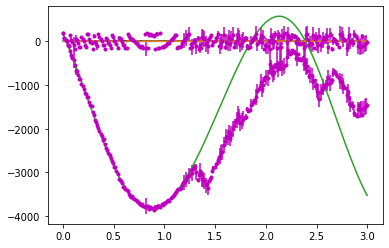

In [ ]:
if True:
    plt.errorbar(tss, f.real, e_f)
    plt.errorbar(tss, f.imag, e_f)
    plt.plot(tss, np.abs(f), c='k')
    plt.errorbar(tss, ang, e_ang, c='m', fmt='.')
    plt.errorbar(tss, unwrapped, e_ang, c='m', fmt='.')
    # plt.xlim(ts[0], ts[800])
    # Very nice coherent variation from start to t~1.3!
    plt.plot(t_int[sel_int], p_int[sel_int])

In [ ]:
pwd

'/cita/h/home-2/montalvo/Pyspace/Scintillometry/Double_Pulsar/Scintillometry'

In [ ]:
montalvo/Pyspace/Scintillometry/Double_Pulsar/Scintillometry/phase_fitter.ipynb

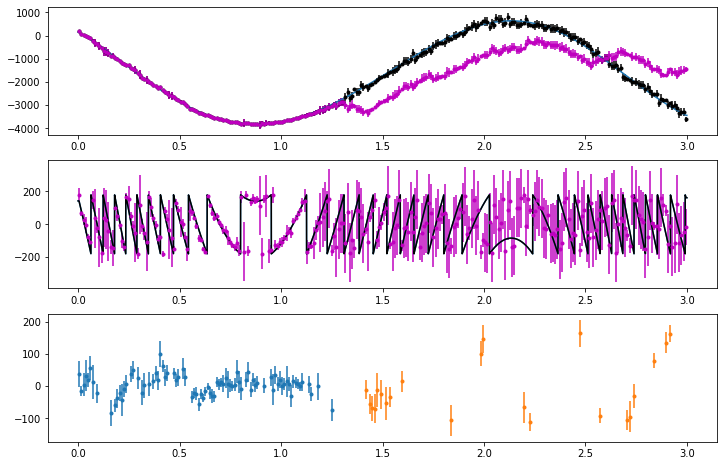

In [ ]:
if True:
    res = wrap180(ang - p_fit)
    plt.figure(figsize=(12,8))
    ax1 = plt.subplot(311)
    plt.errorbar(tss, p_fit + res, e_ang, fmt='.', c='k')
    plt.errorbar(tss, unwrapped, e_ang, c='m', fmt='.')
    plt.plot(t_int, p_int)
    plt.subplot(312, sharex=ax1)
    plt.errorbar(tss, ang, e_ang, c='m', fmt='.')
    plt.plot(t_int, wrap180(p_int))
    plt.plot(t_int[sel_int], wrap180(p_int[sel_int]), c='k')
    plt.subplot(313, sharex=ax1)
    sel = (e_ang < 1*u.rad) & sel_fit
    plt.errorbar(tss[sel], res[sel], e_ang[sel], fmt='.')
    sel = (e_ang < 1*u.rad) & ~sel_fit
    plt.errorbar(tss[sel], res[sel], e_ang[sel], fmt='.')

cang = p_fit * (taus/taus[tau_sel])[:, np.newaxis]
dtaus_corr = dtaus * np.exp(-1j*p_fit.to_value(u.rad))

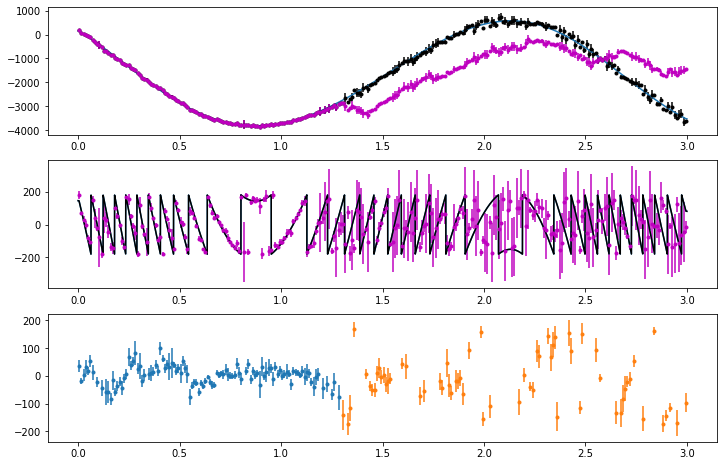

In [ ]:
if True:
    res = wrap180(ang - p_fit)
    plt.figure(figsize=(12,8))
    ax1 = plt.subplot(311)
    plt.errorbar(tss, p_fit + res, e_ang, fmt='.', c='k')
    plt.errorbar(tss, unwrapped, e_ang, c='m', fmt='.')
    plt.plot(t_int, p_int)
    plt.subplot(312, sharex=ax1)
    plt.errorbar(tss, ang, e_ang, c='m', fmt='.')
    plt.plot(t_int, wrap180(p_int))
    plt.plot(t_int[sel_int], wrap180(p_int[sel_int]), c='k')
    plt.subplot(313, sharex=ax1)
    sel = (e_ang < 1*u.rad) & sel_fit
    plt.errorbar(tss[sel], res[sel], e_ang[sel], fmt='.')
    sel = (e_ang < 1*u.rad) & ~sel_fit
    plt.errorbar(tss[sel], res[sel], e_ang[sel], fmt='.')

cang = p_fit * (taus/taus[tau_sel])[:, np.newaxis]
dtaus_corr = dtaus * np.exp(-1j*p_fit.to_value(u.rad))

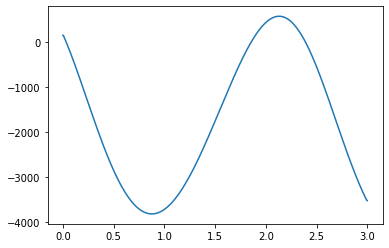

In [ ]:
plt.plot(t_int, p_int)